# Chapter 79 — Numerical Experiments

> **Prerequisites:** ch073 (Error), ch074 (Iteration), ch078 (Simulation)
>
> **You will learn:**
> - Design and run computational experiments on mathematical phenomena
> - Verify theoretical results numerically
> - Investigate conjectures before proving them
> - Use experiments to develop mathematical intuition
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Numerical experiments** treat the computer as a laboratory for mathematics. Before proving a theorem, you run experiments. Before trusting a formula, you verify it. Before building a model, you explore the data.

The experimental cycle:
1. **Hypothesis**: form a precise mathematical conjecture
2. **Design**: choose what to compute, what to vary, what to measure
3. **Execute**: run the computation
4. **Analyze**: look for patterns, measure errors, plot results
5. **Refine or confirm**: update the hypothesis or proceed to proof

**What numerical experiments can do:**
- Verify known results (sanity checks)
- Discover patterns (leads to conjectures)
- Find counterexamples to wrong conjectures
- Estimate constants (π, e, γ, φ)
- Test convergence rates

**What numerical experiments cannot do:**
- Prove theorems (a million examples is not a proof)
- Handle all edge cases
- Distinguish near-zero from exactly zero

---

## 2. Intuition & Mental Models

**Physical analogy:** Galileo dropping balls from the Leaning Tower of Pisa. He ran an experiment before formalizing the laws of gravity. Experiment → pattern → theory. In mathematics the same sequence often applies.

**Computational analogy:** Property-based testing in software. You generate random inputs, run the function, and verify properties hold. If you find a failure, you have a counterexample. This is exactly numerical experimentation applied to code.

---

## 3. Visualization

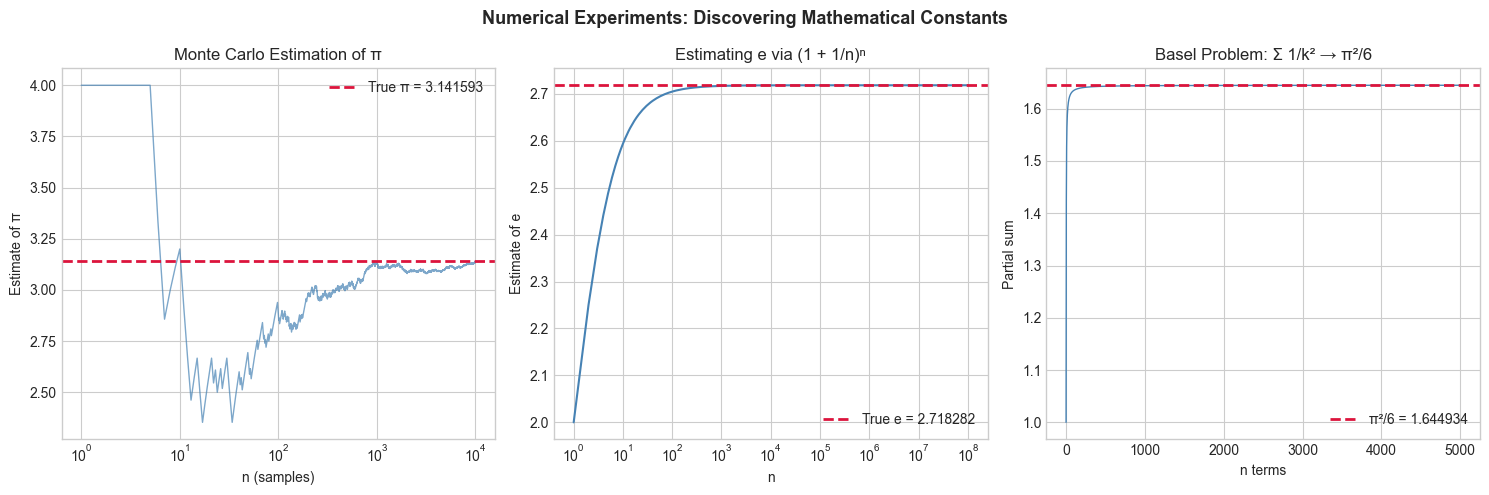

In [1]:
# --- Visualization: Numerical estimation of π and e ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Experiment 1: Monte Carlo estimation of π
n_total = 10000
x = np.random.uniform(-1, 1, n_total)
y = np.random.uniform(-1, 1, n_total)
inside = x**2 + y**2 <= 1
pi_est = 4 * np.cumsum(inside) / np.arange(1, n_total + 1)

axes[0].plot(np.arange(1, n_total + 1), pi_est, color='steelblue', linewidth=1, alpha=0.7)
axes[0].axhline(np.pi, color='crimson', linewidth=2, linestyle='--', label=f'True π = {np.pi:.6f}')
axes[0].set_xscale('log')
axes[0].set_title('Monte Carlo Estimation of π'); axes[0].set_xlabel('n (samples)')
axes[0].set_ylabel('Estimate of π'); axes[0].legend()

# Experiment 2: e as limit of (1+1/n)^n
ns = np.logspace(0, 8, 200).astype(int)
e_est = (1 + 1/ns)**ns
axes[1].semilogx(ns, e_est, color='steelblue', linewidth=1.5)
axes[1].axhline(np.e, color='crimson', linewidth=2, linestyle='--', label=f'True e = {np.e:.6f}')
axes[1].set_title('Estimating e via (1 + 1/n)ⁿ'); axes[1].set_xlabel('n')
axes[1].set_ylabel('Estimate of e'); axes[1].legend()

# Experiment 3: Basel problem - convergence of Σ 1/k² → π²/6
ns_basel = np.arange(1, 5001)
partial_sums = np.cumsum(1 / ns_basel**2)
true_val = np.pi**2 / 6
axes[2].plot(ns_basel, partial_sums, color='steelblue', linewidth=1)
axes[2].axhline(true_val, color='crimson', linewidth=2, linestyle='--', label=f'π²/6 = {true_val:.6f}')
axes[2].set_title('Basel Problem: Σ 1/k² → π²/6'); axes[2].set_xlabel('n terms')
axes[2].set_ylabel('Partial sum'); axes[2].legend()

plt.suptitle('Numerical Experiments: Discovering Mathematical Constants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Experimental verification toolkit ---
import numpy as np

def verify_identity(lhs, rhs, x_range=(-5, 5), n=1000, tol=1e-8):
    """
    Numerically verify that lhs(x) == rhs(x) over x_range.
    
    Args:
        lhs, rhs: callables
        x_range: tuple (a, b)
        n: number of test points
        tol: tolerance for equality check
    Returns:
        dict: verification results
    """
    x = np.linspace(*x_range, n)
    with np.errstate(invalid='ignore', divide='ignore'):
        l_vals = lhs(x)
        r_vals = rhs(x)
    
    # Only check where both sides are finite
    valid = np.isfinite(l_vals) & np.isfinite(r_vals)
    diff = np.abs(l_vals[valid] - r_vals[valid])
    
    return {
        'max_error': diff.max() if len(diff) > 0 else np.inf,
        'mean_error': diff.mean() if len(diff) > 0 else np.inf,
        'n_valid': valid.sum(),
        'passes': diff.max() < tol if len(diff) > 0 else False
    }

# Test classical identities
identities = [
    ("sin²x + cos²x = 1",
     lambda x: np.sin(x)**2 + np.cos(x)**2,
     lambda x: np.ones_like(x)),
    ("exp(log(x)) = x  (x>0)",
     lambda x: np.exp(np.log(np.abs(x))),
     lambda x: np.abs(x), (0.01, 5)),
    ("(a+b)² = a²+2ab+b² for a=x, b=1",
     lambda x: (x + 1)**2,
     lambda x: x**2 + 2*x + 1),
    ("sinh(x) = (exp(x) - exp(-x))/2",
     np.sinh,
     lambda x: (np.exp(x) - np.exp(-x))/2),
]

for entry in identities:
    if len(entry) == 3:
        name, lhs, rhs = entry
        result = verify_identity(lhs, rhs)
    else:
        name, lhs, rhs, xr = entry
        result = verify_identity(lhs, rhs, x_range=xr)
    
    status = "✓ PASS" if result['passes'] else "✗ FAIL"
    print(f"{status} {name}")
    print(f"      max_error={result['max_error']:.2e}, n_valid={result['n_valid']}")

✓ PASS sin²x + cos²x = 1
      max_error=2.22e-16, n_valid=1000
✓ PASS exp(log(x)) = x  (x>0)
      max_error=8.88e-16, n_valid=1000
✓ PASS (a+b)² = a²+2ab+b² for a=x, b=1
      max_error=7.11e-15, n_valid=1000
✓ PASS sinh(x) = (exp(x) - exp(-x))/2
      max_error=1.42e-14, n_valid=1000


---

## 6. Experiments

**Experiment 1:** Test the conjecture "n² + n + 41 is always prime" for n=0, 1, ..., 100. For how long does it hold? Find the first counterexample.

**Experiment 2:** Verify numerically that the harmonic series Σ 1/k diverges by computing partial sums up to n = 10^6. Compare growth rate to log(n).

---

## 7. Exercises

**Easy 1.** Verify numerically: e^(iπ) = -1 (Euler's identity). Use complex numbers in NumPy.

**Easy 2.** For n from 1 to 20, compute n! and confirm it exceeds both 2^n and n^n for large n.

**Medium 1.** Investigate the Collatz conjecture numerically: for all integers 1 to 10000, apply the Collatz sequence and confirm all reach 1. Plot stopping time vs starting number.

**Medium 2.** Numerically estimate the sum Σ 1/k^s for s = 1.5, 2, 3, 4. Does it converge? How many terms do you need for 4-decimal accuracy?

**Hard.** Investigate Goldbach's conjecture numerically: every even integer > 2 is the sum of two primes. Verify for all even integers up to 10000. For each n, find the pair (p, q) with p+q=n and p closest to n/2.

---

## 9. Chapter Summary & Connections

- Numerical experiments: hypothesis → compute → analyze → refine
- Verify identities with `verify_identity`; compute convergence rates; find counterexamples
- Experiments suggest patterns — but 1000 examples is not a proof
- Monte Carlo: use randomness to estimate deterministic quantities (π, integrals)

**Backward connection:** This chapter synthesizes all tools from ch051–078 and applies them experimentally.

**Forward connections:**
- Monte Carlo integration reappears in ch244 (Monte Carlo Methods)
- Experimental verification is the foundation of the scientific computing workflow in Part IX